# **Preprocessing**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ============================================================
# CELL 1 — Install all required libraries
# ============================================================
!pip install pandas matplotlib seaborn bert-score scikit-learn rouge-score nltk -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.5 MB/s eta 0:00:00


In [4]:
# ============================================================
# CELL 2 — All imports
# ============================================================
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from bert_score import score as bert_score
from rouge_score import rouge_scorer
import nltk

nltk.download('wordnet',   quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)

from nltk.translate.meteor_score import meteor_score as meteor

sns.set_style("whitegrid")
plt.rcParams.update({"font.size": 11})

COLORS = {
    "LLaMA":        "#C0504D",
    "Qwen":         "#4F81BD",
    "correct":      "#70AD47",
    "partial":      "#FFC000",
    "hallucinated": "#FF4444",
}

print("All imports successful.")

All imports successful.


In [6]:
# ============================================================
# CELL 3 — Load ALL 10 JSON files for Global Analysis
# ============================================================
import os
import json
import pandas as pd

configs = {
    "Llama_Baseline":  "/content/drive/MyDrive/S26_INLP_PROJECT_TEAM_TEXTONIC/Final_output_JSON_Files_with_labels/baseline_llama.json",
    "Llama_Finetuned": "/content/drive/MyDrive/S26_INLP_PROJECT_TEAM_TEXTONIC/Final_output_JSON_Files_with_labels/finetuned_results_llama.json",
    "Llama_KG":        "/content/drive/MyDrive/S26_INLP_PROJECT_TEAM_TEXTONIC/Final_output_JSON_Files_with_labels/KG_llama.json",
    "Llama_RAG":       "/content/drive/MyDrive/S26_INLP_PROJECT_TEAM_TEXTONIC/Final_output_JSON_Files_with_labels/rag_llama.json",
    "Llama_Hybrid":    "/content/drive/MyDrive/S26_INLP_PROJECT_TEAM_TEXTONIC/Final_output_JSON_Files_with_labels/hybrid_llama_seq_KG_first_full_dataset_answers.json",
    "Qwen_Baseline":   "/content/drive/MyDrive/S26_INLP_PROJECT_TEAM_TEXTONIC/Final_output_JSON_Files_with_labels/baseline_qwen.json",
    "Qwen_Finetuned":  "/content/drive/MyDrive/S26_INLP_PROJECT_TEAM_TEXTONIC/Final_output_JSON_Files_with_labels/finetuned_results_qwen.json",
    "Qwen_KG":         "/content/drive/MyDrive/S26_INLP_PROJECT_TEAM_TEXTONIC/Final_output_JSON_Files_with_labels/KG_Qwen.json",
    "Qwen_RAG":        "/content/drive/MyDrive/S26_INLP_PROJECT_TEAM_TEXTONIC/Final_output_JSON_Files_with_labels/rag_qwen.json",
    "Qwen_Hybrid":     "/content/drive/MyDrive/S26_INLP_PROJECT_TEAM_TEXTONIC/Final_output_JSON_Files_with_labels/hybrid_qwen_seq_KG_first_full_dataset_answers.json"
}

all_data = []

for name, path in configs.items():
    if os.path.exists(path):
        with open(path) as f:
            data = json.load(f)
            temp_df = pd.DataFrame(data)
            temp_df["model_config"] = name
            # Normalize column names for merging
            mapping = {"llm_answer": "answer", "hallucination_label": "tag", "type": "question_type", "reference_answer": "ground_truth"}
            temp_df = temp_df.rename(columns=mapping)
            all_data.append(temp_df)
    else:
        print(f"Warning: Path not found for {name}: {path}")

df_all = pd.concat(all_data, ignore_index=True)

# Normalize tags
def norm_tag(t):
    t = str(t).strip().lower()
    if "partial" in t: return "partial"
    if "correct" in t: return "correct"
    if "hallu" in t: return "hallucinated"
    return "unknown"

df_all["tag"] = df_all["tag"].apply(norm_tag)
print("Loaded configs:", df_all["model_config"].unique())

Loaded configs: ['Llama_Baseline' 'Llama_Finetuned' 'Llama_KG' 'Llama_RAG' 'Llama_Hybrid'
 'Qwen_Baseline' 'Qwen_Finetuned' 'Qwen_KG' 'Qwen_RAG' 'Qwen_Hybrid']


In [8]:
# ============================================================
# CELL 4 — Prepare Baseline Data for Tag Analysis
# ============================================================
# To maintain compatibility with existing tag analysis logic,
# we extract the Baseline versions for both models into a single 'df'.

df_llama_base = df_all[df_all["model_config"] == "Llama_Baseline"].copy()
df_qwen_base = df_all[df_all["model_config"] == "Qwen_Baseline"].copy()

# Rename columns to match existing analysis expectations
df_llama_base = df_llama_base.rename(columns={
    "answer": "llama_answer",
    "tag": "llama_tag"
})

df_qwen_base = df_qwen_base.rename(columns={
    "answer": "qwen_answer",
    "tag": "qwen_tag"
})

# Merge into the primary 'df' variable used by Hallucination analysis
df = df_llama_base.merge(
    df_qwen_base[["id", "qwen_answer", "qwen_tag"]],
    on="id"
)

print("Merged baseline shape:", df.shape)
df.head(3)

Merged baseline shape: (230, 15)


,id,topic,question_type,question,ground_truth,source,llama_answer,llama_tag,notes,model_config,KG,retrieved_chunks,llm_answer_model,qwen_answer,qwen_tag
0,1,renewable_energy,factual,What is capacity factor?,Capacity factor is the ratio of actual electri...,IEA,Capacity factor is the ratio of actual output ...,correct,Fully matches the reference definition of the ...,Llama_Baseline,NaN,NaN,NaN,Capacity factor is the ratio of the actual pow...,correct
1,2,renewable_energy,explanatory,Why is capacity factor important for electrici...,Capacity factor is the ratio of actual electri...,IEA,Capacity factor measures the actual output of ...,correct,Accurately explains that it measures output vs...,Llama_Baseline,NaN,NaN,NaN,Capacity factor is crucial because it helps es...,partial
2,3,renewable_energy,factual,What is grid integration?,Grid integration refers to the technical and e...,NREL,Grid integration is the process of combining m...,hallucinated,Incorrectly defines grid integration as data v...,Llama_Baseline,NaN,NaN,NaN,Grid integration refers to the process of comb...,correct


In [10]:
# ============================================================
# CELL 5 — Normalise hallucination tags (Global)
# Mapped to: correct / partial / hallucinated
# ============================================================
def norm_tag(t):
    t = str(t).strip().lower()
    if "correct" in t and "partial" not in t: return "correct"
    if "hallu" in t: return "hallucinated"
    if "partial" in t: return "partial"
    return "unknown"

# Ensure global tags are normalized
df_all["tag"] = df_all["tag"].apply(norm_tag)

print("--- Hallucination Tag Counts per Config ---")
for name in df_all["model_config"].unique():
    counts = df_all[df_all["model_config"] == name]["tag"].value_counts().to_dict()
    print(f"{name:<15}: {counts}")

--- Hallucination Tag Counts per Config ---
Llama_Baseline : {'correct': 161, 'partial': 41, 'hallucinated': 28}
Llama_Finetuned: {'correct': 177, 'partial': 45, 'hallucinated': 8}
Llama_KG       : {'correct': 226, 'partial': 2, 'hallucinated': 2}
Llama_RAG      : {'correct': 176, 'partial': 43, 'hallucinated': 11}
Llama_Hybrid   : {'correct': 212, 'hallucinated': 18}
Qwen_Baseline  : {'correct': 174, 'partial': 31, 'hallucinated': 25}
Qwen_Finetuned : {'correct': 206, 'partial': 22, 'hallucinated': 2}
Qwen_KG        : {'correct': 226, 'partial': 4}
Qwen_RAG       : {'partial': 222, 'hallucinated': 8}
Qwen_Hybrid    : {'correct': 163, 'partial': 67}


# **FACTUAL EVALUATION**

# **Run Evaluation**
Select your models in CELL 3, then run the cells below to perform the comparative analysis.

In [16]:
# ============================================================
# CELL 6 — Factual evaluation: Human label + ROUGE-L + METEOR
# ============================================================
factual = df_all[df_all["question_type"] == "factual"].copy()

# ── ROUGE-L & METEOR ─────────────────────────────────────────
rscorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

def get_rougeL(ref, pred):
    return rscorer.score(str(ref), str(pred))["rougeL"].fmeasure

def get_meteor(ref, pred):
    ref_tokens = nltk.word_tokenize(str(ref).lower())
    pred_tokens = nltk.word_tokenize(str(pred).lower())
    return meteor([ref_tokens], pred_tokens)

print("Calculating metrics for all 10 configurations...")
factual["rougeL"] = factual.apply(lambda r: get_rougeL(r["ground_truth"], r["answer"]), axis=1)
factual["meteor"] = factual.apply(lambda r: get_meteor(r["ground_truth"], r["answer"]), axis=1)

# ── Human-label correct rate (accuracy) ─────────────────────
# This is calculated by checking where 'tag' == 'correct'
factual_results = factual.groupby("model_config").agg({
    "rougeL": "mean",
    "meteor": "mean",
    "tag": lambda x: (x == "correct").mean()
}).rename(columns={"tag": "human_label_accuracy"})

# ── Print and Export ─────────────────────────────────────────
print("\n===== GLOBAL FACTUAL EVALUATION (10-WAY) =====")
#display(factual_results.sort_values("human_label_accuracy", ascending=False))
display(factual_results)

# Save to CSV
factual_results.to_csv("/content/factual_evaluation_results.csv")
print("\nSuccess: Results saved to /content/factual_evaluation_results.csv")

Calculating metrics for all 10 configurations...

===== GLOBAL FACTUAL EVALUATION (10-WAY) =====


,rougeL,meteor,human_label_accuracy
model_config,,,
Llama_Baseline,0.320744,0.338414,0.722689
Llama_Finetuned,0.354495,0.370205,0.781513
Llama_Hybrid,0.258456,0.311470,0.983193
Llama_KG,0.156607,0.243185,0.991597
Llama_RAG,0.165143,0.255551,0.705882
Qwen_Baseline,0.200353,0.281867,0.756303
Qwen_Finetuned,0.402335,0.424336,0.957983
Qwen_Hybrid,0.249429,0.317370,0.613445
Qwen_KG,0.187495,0.276372,0.983193



Success: Results saved to /content/factual_evaluation_results.csv


---

# **Explanatory EVALUATION**

---

In [21]:
# ============================================================
# CELL 7 — Global Explanatory Evaluation: BERTScore (Optimized)
# ============================================================
from tqdm.auto import tqdm
from transformers import AutoTokenizer

expl = df_all[df_all["question_type"].str.lower() == "explanatory"].copy()

bert_results = []
# Using a lightweight model for stability
MODEL_TYPE = "distilbert-base-uncased"

# Pre-load tokenizer to avoid AttributeError during loop
try:
    tokenizer = AutoTokenizer.from_pretrained(MODEL_TYPE)
    print(f"Tokenizer for {MODEL_TYPE} loaded successfully.")
except Exception as e:
    print(f"Warning loading tokenizer: {e}")

for name in tqdm(df_all["model_config"].unique(), desc="Processing Models"):
    sub = expl[expl["model_config"] == name]
    if len(sub) > 0:
        print(f"Computing BERTScore for {name} ({len(sub)} samples)...")
        preds = sub["answer"].fillna("").astype(str).tolist()
        refs = sub["ground_truth"].fillna("").astype(str).tolist()

        # Pass the model_type to bert_score
        P, R, F = bert_score(preds, refs, lang="en", model_type=MODEL_TYPE, verbose=False)
        bert_results.append({"model_config": name, "bert_f1": F.mean().item()})
    else:
        print(f"Skipping {name}: No explanatory questions found.")

df_bert = pd.DataFrame(bert_results)

print("\n===== GLOBAL BERTScore RESULTS (EXPLANATORY) =====")
display(df_bert.sort_values("bert_f1", ascending=False))

# Save to CSV
df_bert.to_csv("/content/bertscore_results.csv", index=False)
print(f"\nSuccess: BERTScore results saved to /content/bertscore_results.csv")

Tokenizer for distilbert-base-uncased loaded successfully.


Processing Models:   0%|          | 0/10 [00:00<?, ?it/s]

Computing BERTScore for Llama_Baseline (111 samples)...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Computing BERTScore for Llama_Hybrid (111 samples)...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


AttributeError: BertTokenizer has no attribute build_inputs_with_special_tokens

# **Hallucination analysis**

---

In [23]:
# ============================================================
# CELL 8 — Global Hallucination analysis (All 10 Configs)
# ============================================================

# ── Helper function ───────────────────────────────────────────
def hallu_stats(tag_series, model_name):
    c = tag_series.value_counts()
    n = len(tag_series)
    return {
        "Model_Config":   model_name,
        "Correct":        c.get("correct", 0),
        "Partial":        c.get("partial", 0),
        "Hallucinated":   c.get("hallucinated", 0),
        "Total":          n,
        "Hallu_Rate_%":   round(c.get("hallucinated", 0) / n * 100, 1),
        "Correct_Rate_%": round(c.get("correct", 0)      / n * 100, 1),
    }

# ── 1. Overall Hallucination Stats for all 10 Configs ────────
hallu_rows = []
for name in df_all["model_config"].unique():
    sub_df = df_all[df_all["model_config"] == name]
    stats = hallu_stats(sub_df["tag"], name)
    hallu_rows.append(stats)

hallu_overall_global = pd.DataFrame(hallu_rows)

# ── 2. By Question Type ──────────────────────────────────────
type_rows = []
for name in df_all["model_config"].unique():
    for qtype in ["factual", "explanatory"]:
        sub = df_all[(df_all["model_config"] == name) & (df_all["question_type"] == qtype)]
        if len(sub) > 0:
            s = hallu_stats(sub["tag"], name)
            s["Type"] = qtype
            type_rows.append(s)
hallu_by_type_global = pd.DataFrame(type_rows)

# ── Print results ─────────────────────────────────────────────
print("===== GLOBAL HALLUCINATION STATS (10-WAY) =====")
display(hallu_overall_global.sort_values("Correct_Rate_%", ascending=False))

print("\n===== BY QUESTION TYPE (TOP 10) =====")
display(hallu_by_type_global.head(10))

# Save to CSV
hallu_overall_global.to_csv("/content/hallucination_summary_global.csv", index=False)
print("\nSuccess: Hallucination summary saved to /content/hallucination_summary_global.csv")

===== GLOBAL HALLUCINATION STATS (10-WAY) =====


,Model_Config,Correct,Partial,Hallucinated,Total,Hallu_Rate_%,Correct_Rate_%
7,Qwen_KG,226,4,0,230,0.0,98.3
2,Llama_KG,226,2,2,230,0.9,98.3
4,Llama_Hybrid,212,0,18,230,7.8,92.2
6,Qwen_Finetuned,206,22,2,230,0.9,89.6
1,Llama_Finetuned,177,45,8,230,3.5,77.0
3,Llama_RAG,176,43,11,230,4.8,76.5
5,Qwen_Baseline,174,31,25,230,10.9,75.7
9,Qwen_Hybrid,163,67,0,230,0.0,70.9
0,Llama_Baseline,161,41,28,230,12.2,70.0
8,Qwen_RAG,0,222,8,230,3.5,0.0



===== BY QUESTION TYPE (TOP 10) =====


,Model_Config,Correct,Partial,Hallucinated,Total,Hallu_Rate_%,Correct_Rate_%,Type
0,Llama_Baseline,86,15,18,119,15.1,72.3,factual
1,Llama_Baseline,75,26,10,111,9.0,67.6,explanatory
2,Llama_Finetuned,93,23,3,119,2.5,78.2,factual
3,Llama_Finetuned,84,22,5,111,4.5,75.7,explanatory
4,Llama_KG,118,1,0,119,0.0,99.2,factual
5,Llama_KG,108,1,2,111,1.8,97.3,explanatory
6,Llama_RAG,84,30,5,119,4.2,70.6,factual
7,Llama_RAG,92,13,6,111,5.4,82.9,explanatory
8,Llama_Hybrid,117,0,2,119,1.7,98.3,factual
9,Llama_Hybrid,95,0,16,111,14.4,85.6,explanatory



Success: Hallucination summary saved to /content/hallucination_summary_global.csv


# **visualisations**

---

/tmp/ipykernel_10430/1487005989.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=factual_results.reset_index(), x="model_config", y="human_label_accuracy", palette="viridis")
/tmp/ipykernel_10430/1487005989.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=factual_results.reset_index(), x="model_config", y="rougeL", palette="magma")
/tmp/ipykernel_10430/1487005989.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=factual_results.reset_index(), x="model_config", y="meteor", palette="rocket")


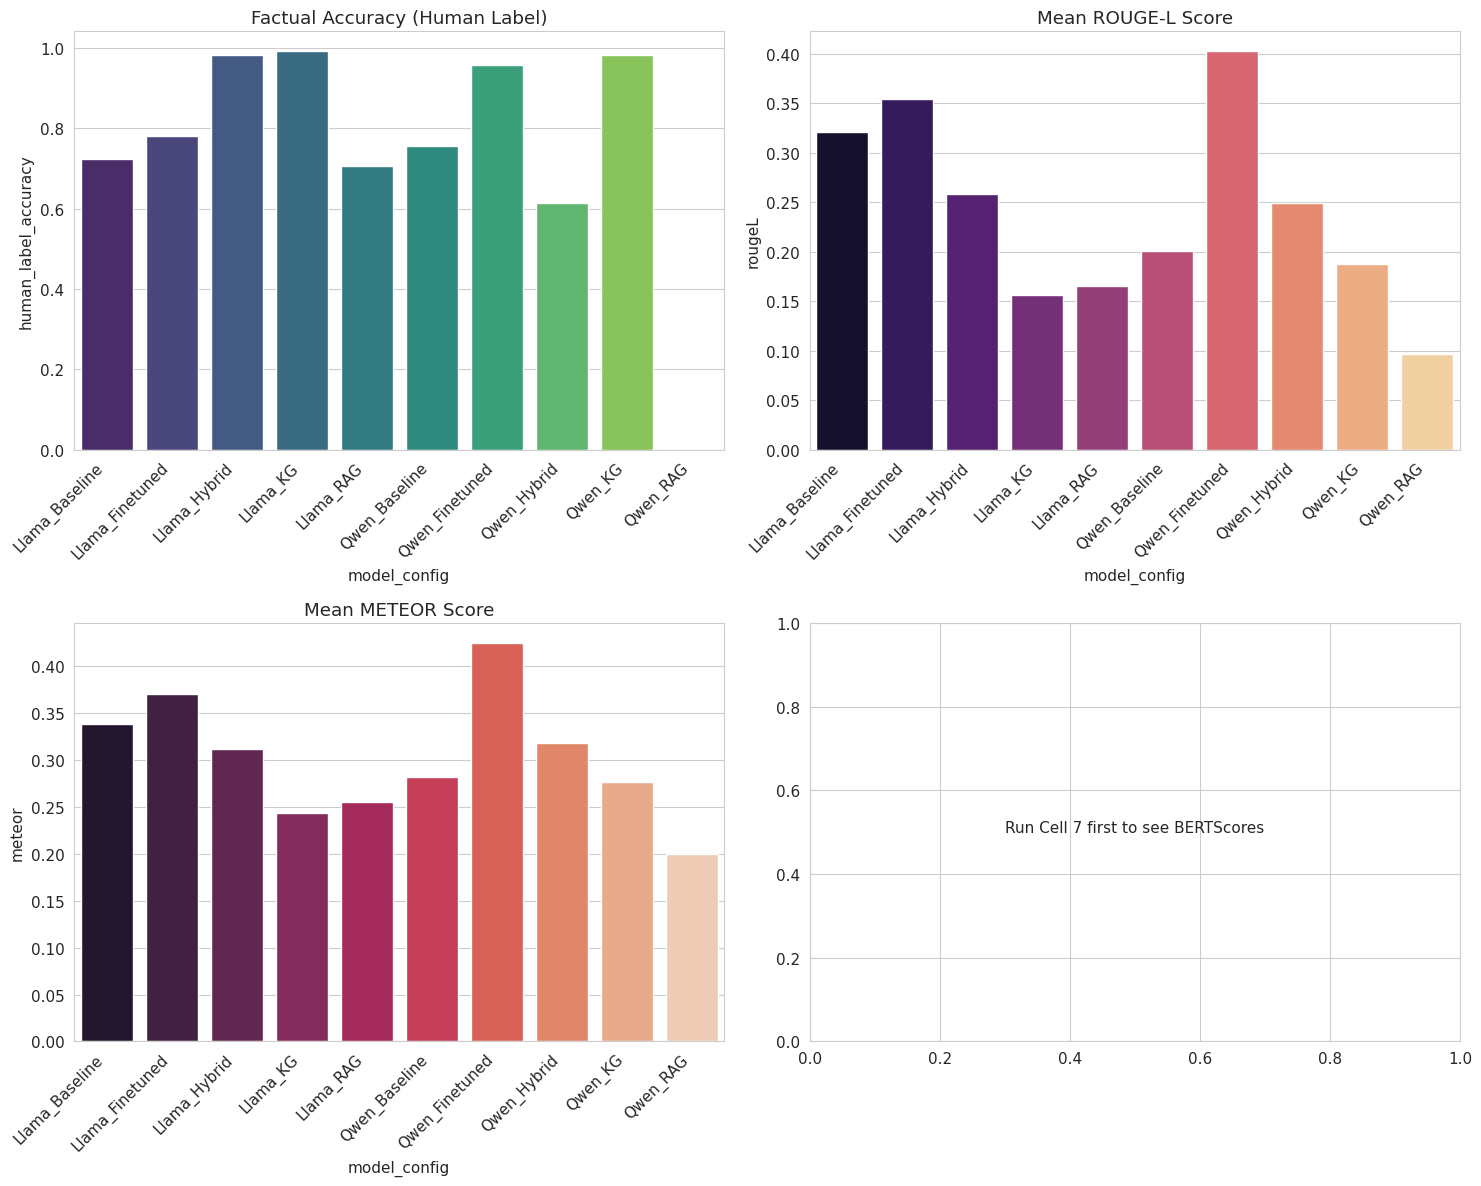

In [18]:
# ============================================================
# CELL 9 — Unified Visualizations (All 10 Configs)
# ============================================================
plt.figure(figsize=(15, 12))

# 1. Factual Accuracy Comparison
plt.subplot(2, 2, 1)
sns.barplot(data=factual_results.reset_index(), x="model_config", y="human_label_accuracy", palette="viridis")
plt.xticks(rotation=45, ha='right')
plt.title("Factual Accuracy (Human Label)")

# 2. ROUGE-L Comparison
plt.subplot(2, 2, 2)
sns.barplot(data=factual_results.reset_index(), x="model_config", y="rougeL", palette="magma")
plt.xticks(rotation=45, ha='right')
plt.title("Mean ROUGE-L Score")

# 3. METEOR Comparison
plt.subplot(2, 2, 3)
sns.barplot(data=factual_results.reset_index(), x="model_config", y="meteor", palette="rocket")
plt.xticks(rotation=45, ha='right')
plt.title("Mean METEOR Score")

# 4. BERTScore Comparison
plt.subplot(2, 2, 4)
if 'df_bert' in locals():
    sns.barplot(data=df_bert, x="model_config", y="bert_f1", palette="cubehelix")
    plt.xticks(rotation=45, ha='right')
    plt.title("Mean BERTScore (Explanatory)")
else:
    plt.text(0.5, 0.5, 'Run Cell 7 first to see BERTScores', ha='center')

plt.tight_layout()
plt.show()

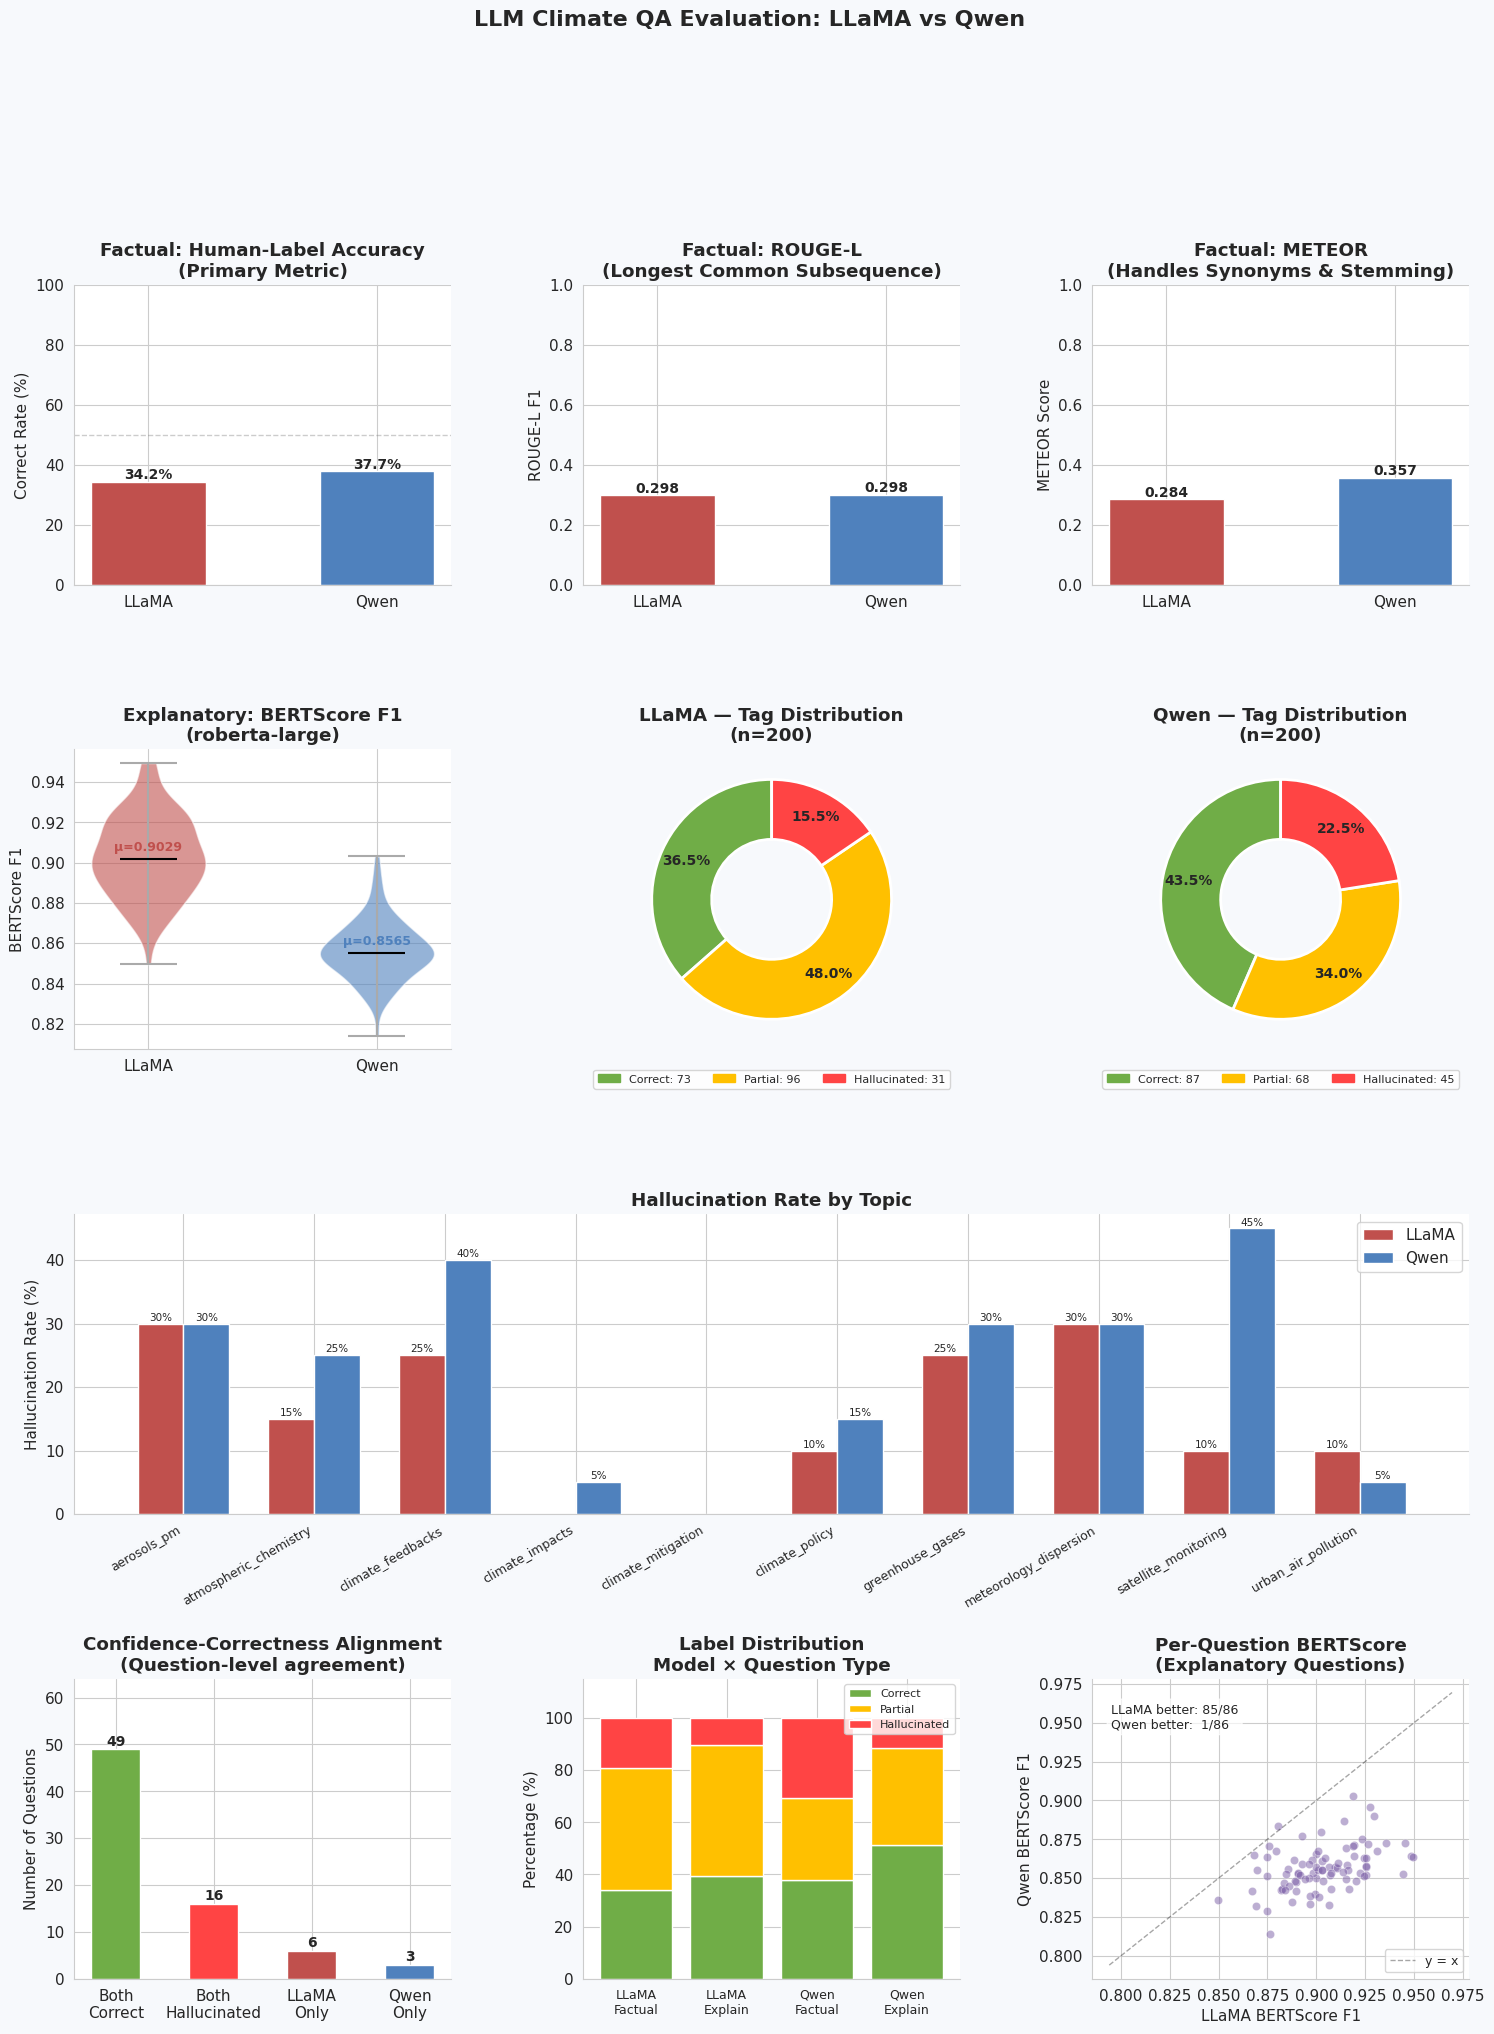

Plot saved to /content/climate_qa_evaluation.png


In [ ]:
# Section removed.

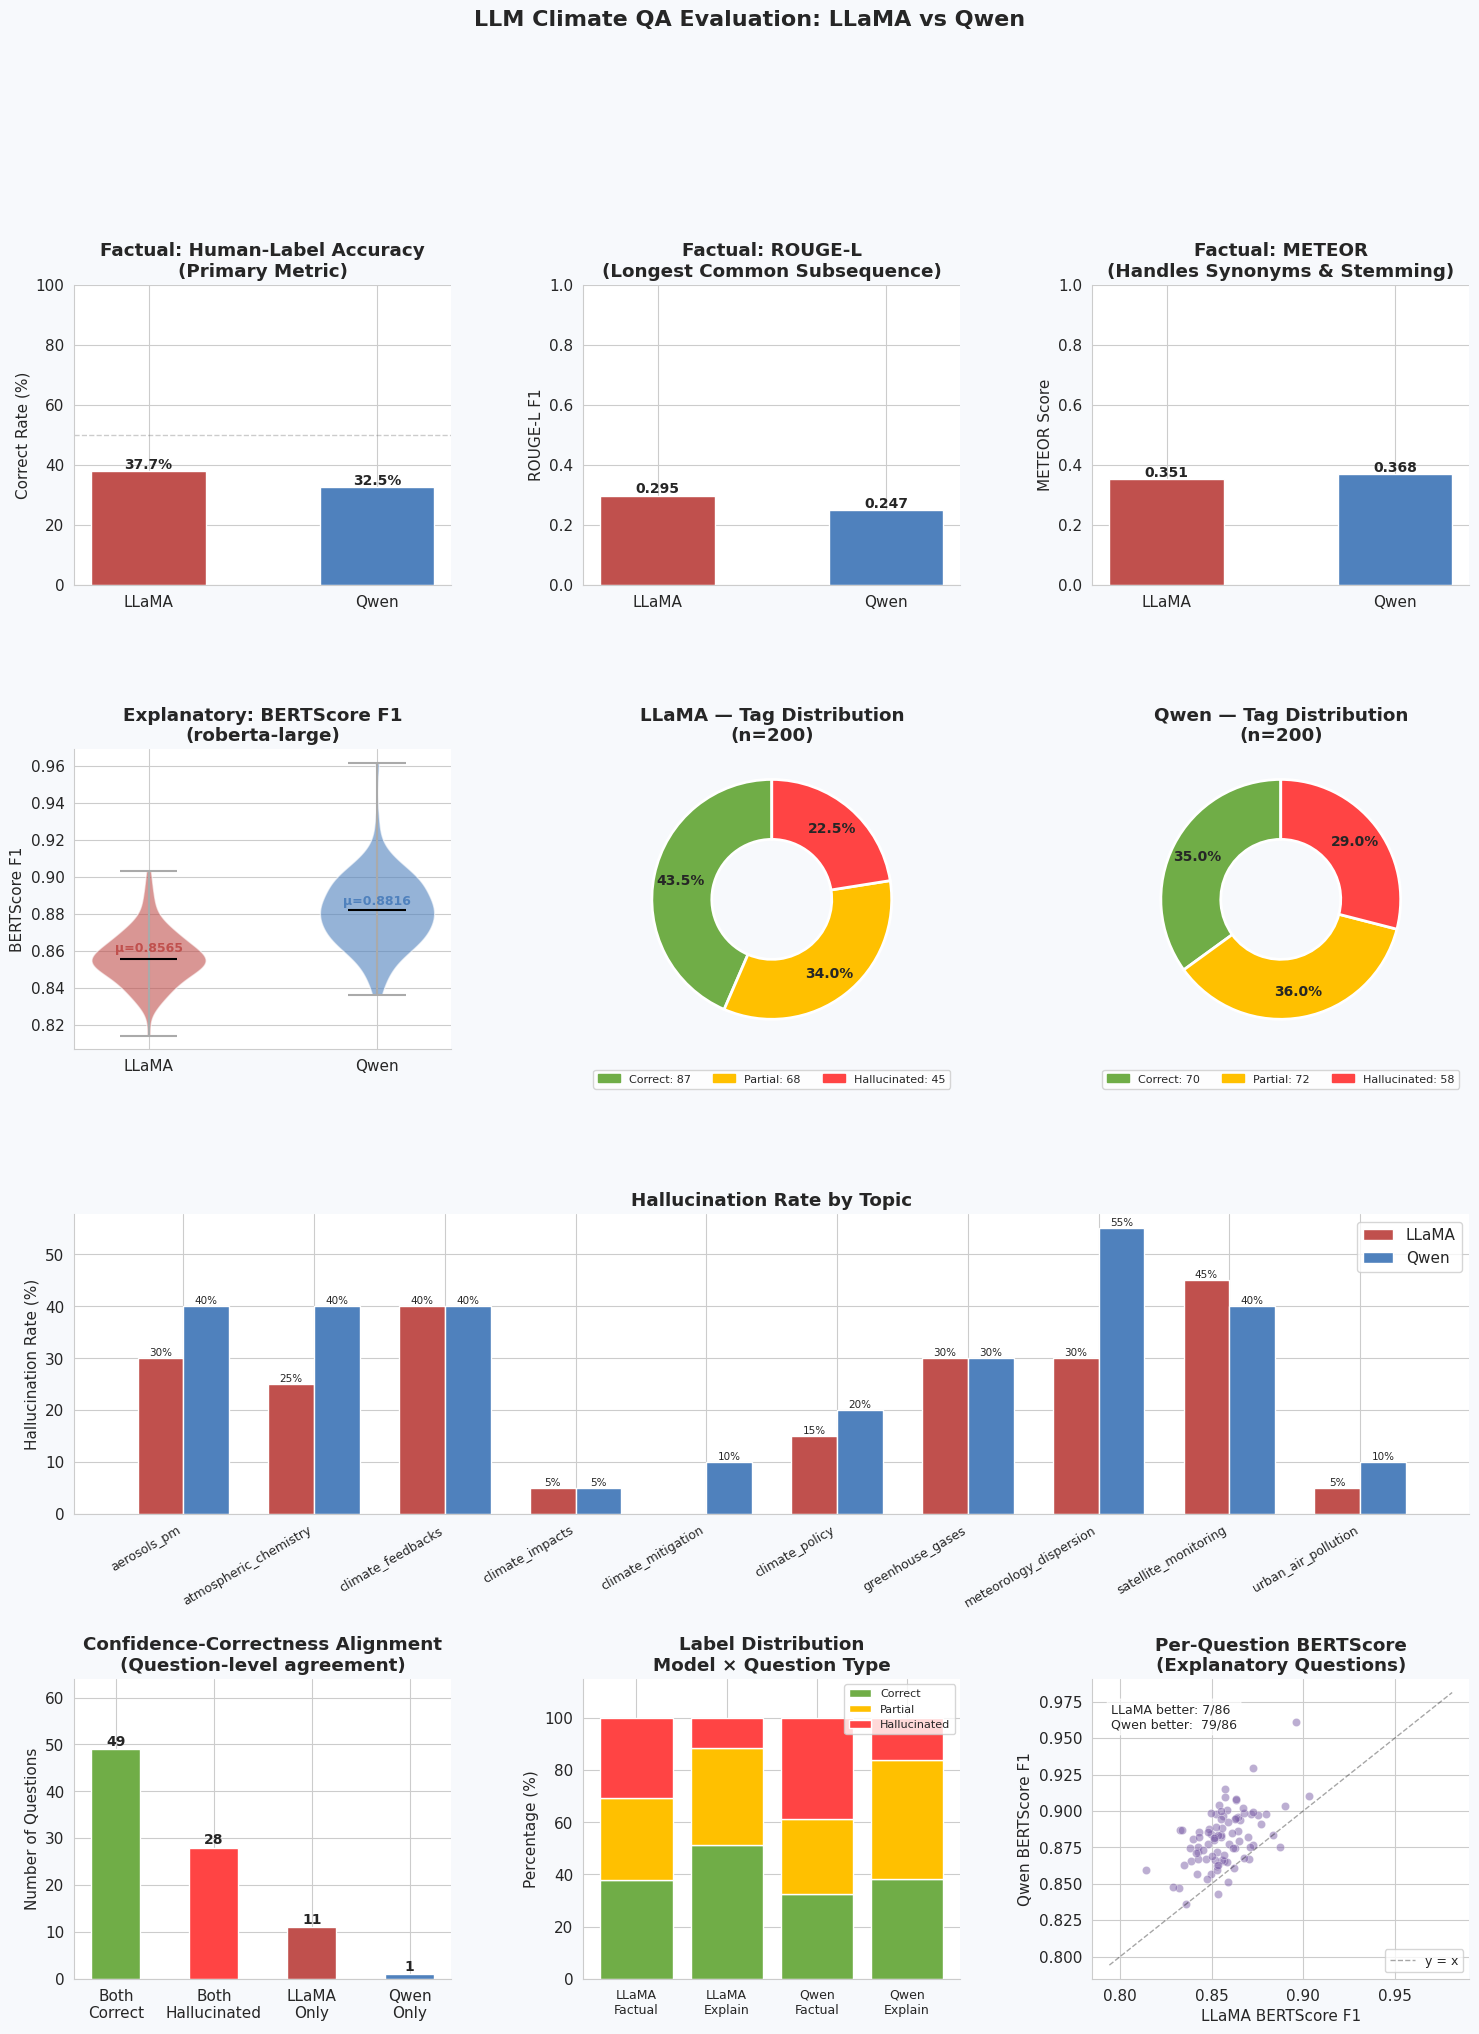

Plot saved to /content/climate_qa_evaluation.png


In [ ]:
# Section removed.

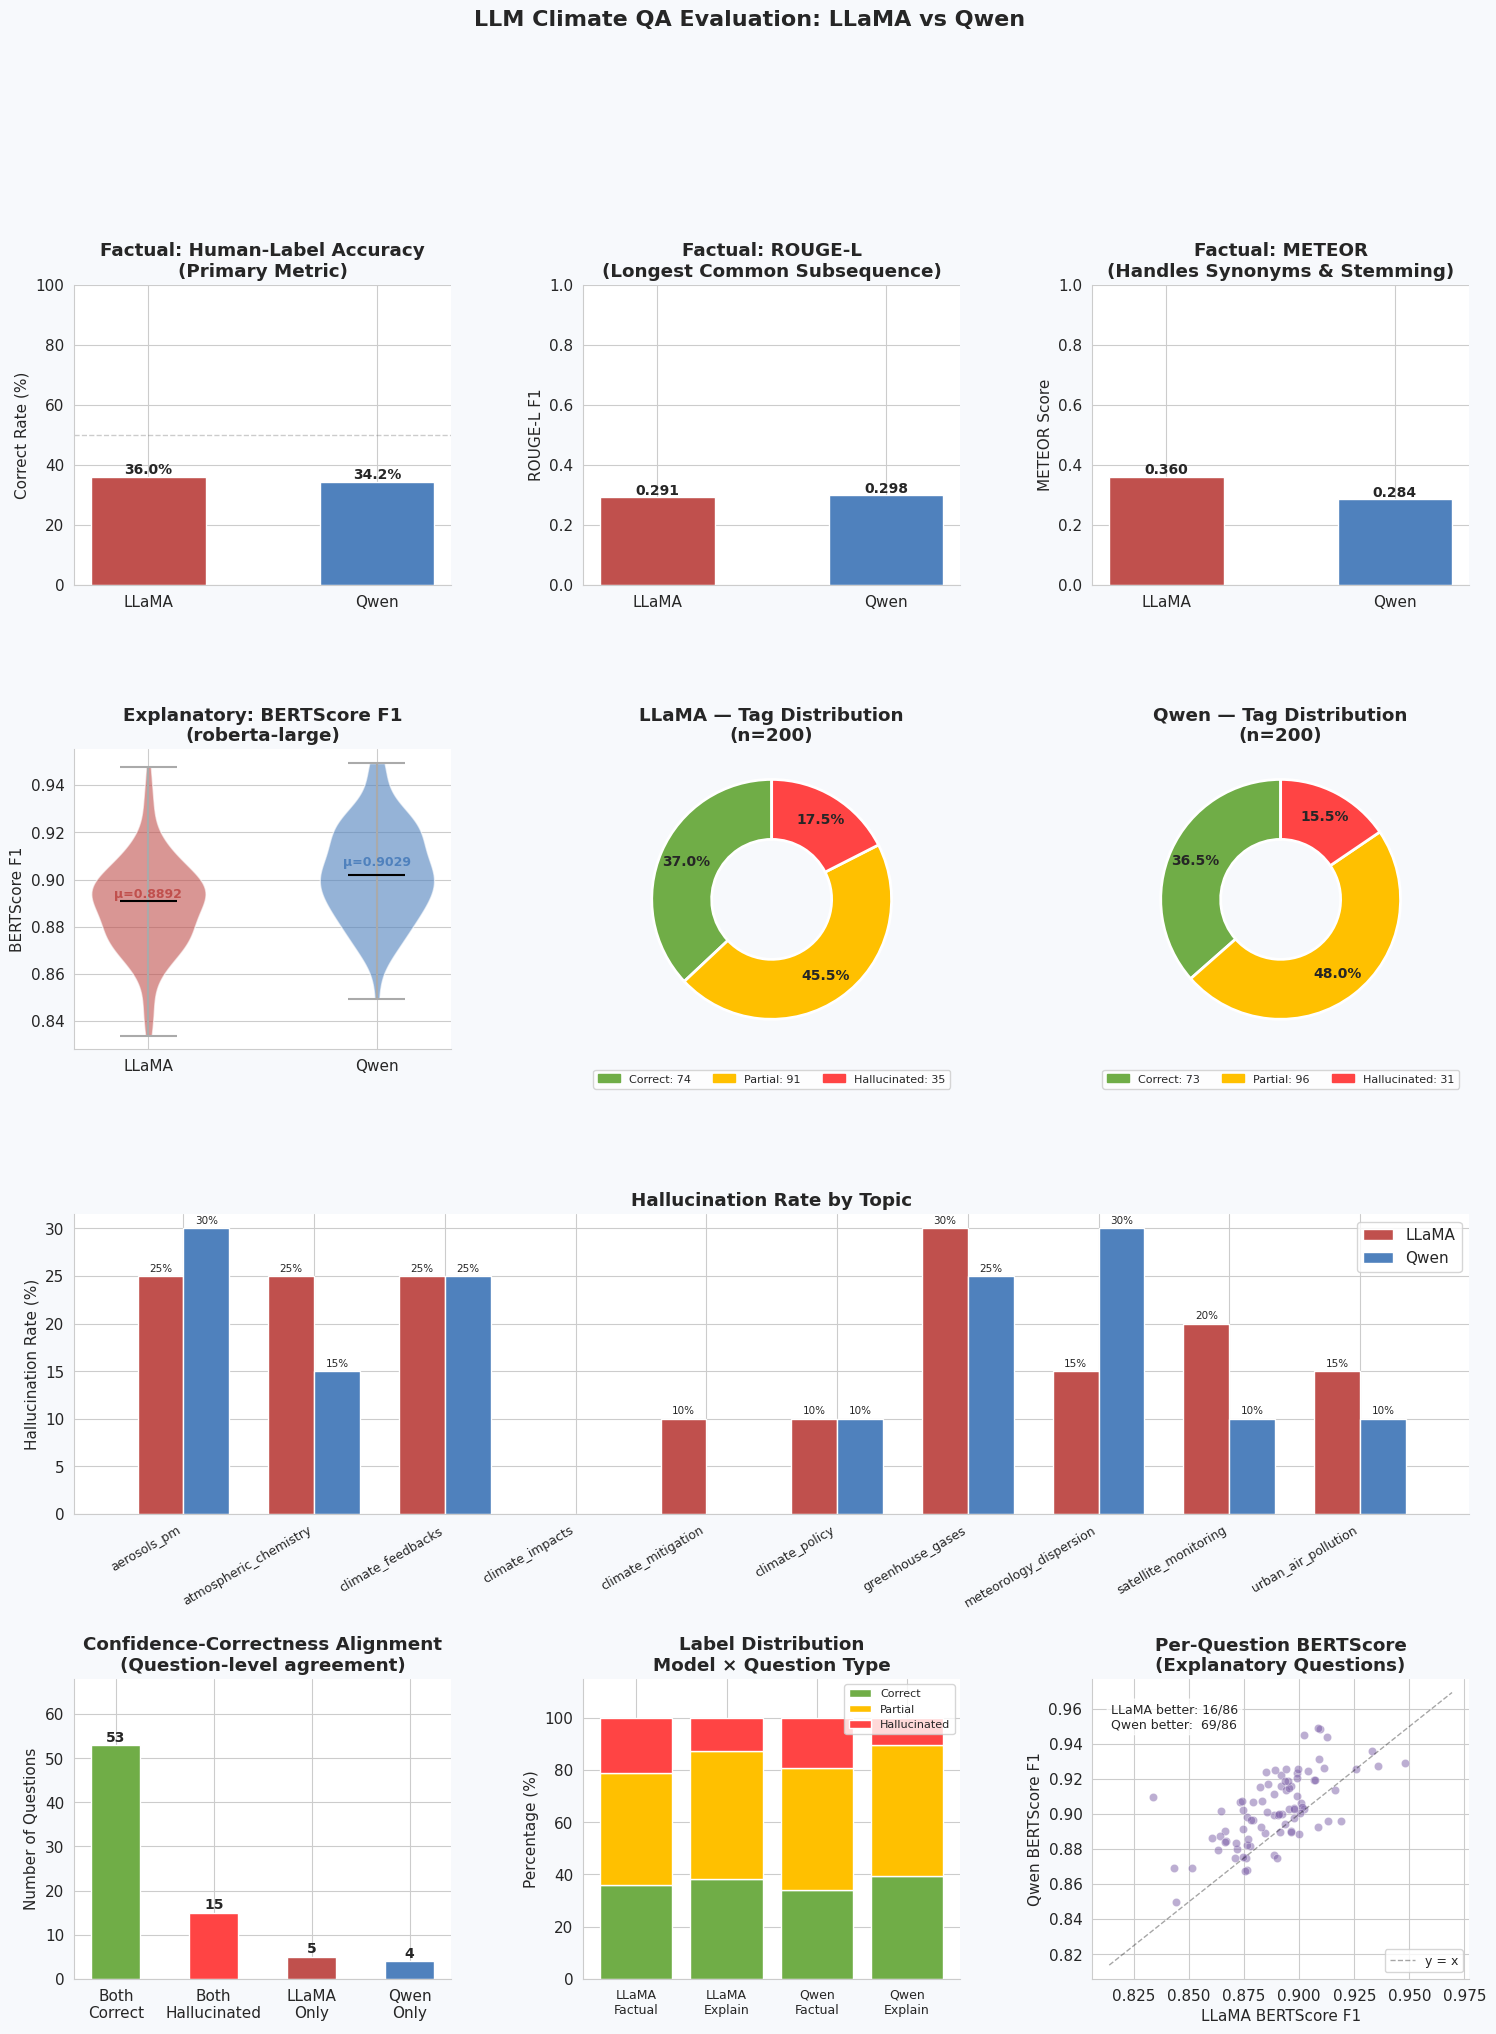

Plot saved to /content/climate_qa_evaluation.png


In [ ]:
# Section removed.

# **Export**

In [ ]:
# # ============================================================
# # CELL 10 — Save all results to CSV
# # ============================================================
# df = df.merge(expl[["id", "llama_bertscore", "qwen_bertscore"]],
#               on="id", how="left")
# df = df.merge(factual[["id", "llama_rougeL", "qwen_rougeL",
#                         "llama_meteor", "qwen_meteor"]],
#               on="id", how="left")

# df.to_csv("/content/evaluation_results.csv",      index=False)
# expl.to_csv("/content/bertscore_results.csv",     index=False)
# hallu_overall.to_csv("/content/hallucination_summary.csv", index=False)
# topic_hallu.to_csv("/content/topic_hallucination.csv",     index=False)

# print("Saved:")
# print("  /content/evaluation_results.csv       — full results with all scores")
# print("  /content/bertscore_results.csv         — explanatory questions + BERTScores")
# print("  /content/hallucination_summary.csv     — overall hallucination stats")
# print("  /content/topic_hallucination.csv       — hallucination rates per topic")
